<a href="https://colab.research.google.com/github/samrudhimadane6-creator/Customer-Segmentation/blob/main/Customer_Segmentation_Project_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn plotly openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import plotly.express as px

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
data = {
    "CustomerID": range(1, 21),

    "Age": [
        22, 25, 28, 35, 40,
        45, 50, 52, 30, 27,
        33, 38, 42, 48, 55,
        60, 23, 29, 36, 44
    ],

    "AnnualIncome": [
        25000, 30000, 35000, 50000, 60000,
        70000, 80000, 90000, 45000, 32000,
        55000, 65000, 75000, 85000, 95000,
        100000, 28000, 40000, 58000, 72000
    ],

    "SpendingScore": [
        80, 75, 85, 60, 40,
        30, 25, 20, 70, 82,
        55, 45, 35, 28, 18,
        15, 78, 88, 50, 32
    ],

    "PurchaseFrequency": [
        12, 10, 14, 8, 6,
        4, 3, 2, 11, 13,
        7, 6, 5, 3, 2,
        1, 12, 15, 7, 4
    ]
}

df = pd.DataFrame(data)

df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency
0,1,22,25000,80,12
1,2,25,30000,75,10
2,3,28,35000,85,14
3,4,35,50000,60,8
4,5,40,60000,40,6


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (20, 5)

Columns:
['CustomerID', 'Age', 'AnnualIncome', 'SpendingScore', 'PurchaseFrequency']

Missing Values:
CustomerID           0
Age                  0
AnnualIncome         0
SpendingScore        0
PurchaseFrequency    0
dtype: int64


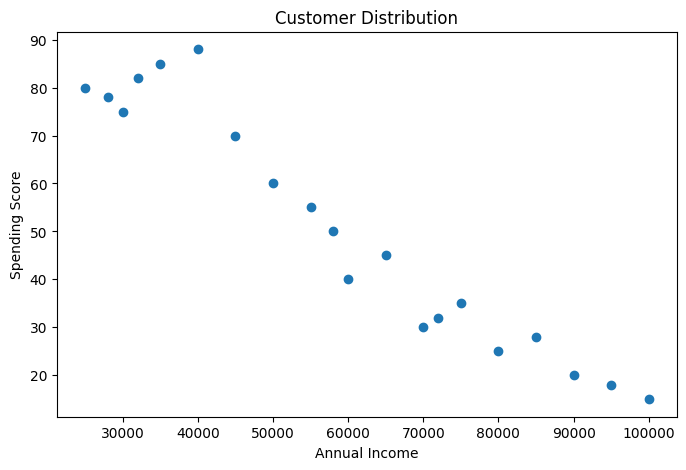

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["AnnualIncome"],
    df["SpendingScore"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")

plt.show()

In [6]:
features = [
    "AnnualIncome",
    "SpendingScore",
    "PurchaseFrequency"
]

X = df[features]

X.head()

,AnnualIncome,SpendingScore,PurchaseFrequency
0,25000,80,12
1,30000,75,10
2,35000,85,14
3,50000,60,8
4,60000,40,6


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.50206   ,  1.20972616,  1.1107503 ],
       [-1.28437015,  1.00433971,  0.64306596],
       [-1.06668029,  1.4151126 ,  1.57843464],
       [-0.41361073,  0.38818038,  0.17538163],
       [ 0.02176899, -0.4333654 , -0.29230271]])

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency,Cluster
0,1,22,25000,80,12,1
1,2,25,30000,75,10,1
2,3,28,35000,85,14,1
3,4,35,50000,60,8,2
4,5,40,60000,40,6,2


In [9]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print("Customers in Each Segment:")
print(cluster_counts)

Customers in Each Segment:
Cluster
0    4
1    7
2    5
3    4
Name: count, dtype: int64


In [10]:
# Analyze each customer segment

segment_analysis = df.groupby("Cluster")[
    ["Age", "AnnualIncome", "SpendingScore", "PurchaseFrequency"]
].mean().round(2)

print("Customer Segment Analysis:")
print(segment_analysis)

Customer Segment Analysis:
           Age  AnnualIncome  SpendingScore  PurchaseFrequency
Cluster                                                       
0        45.25      74250.00          30.50               4.00
1        26.29      33571.43          79.71              12.43
2        36.40      57600.00          50.00               6.80
3        53.75      92500.00          20.25               2.00


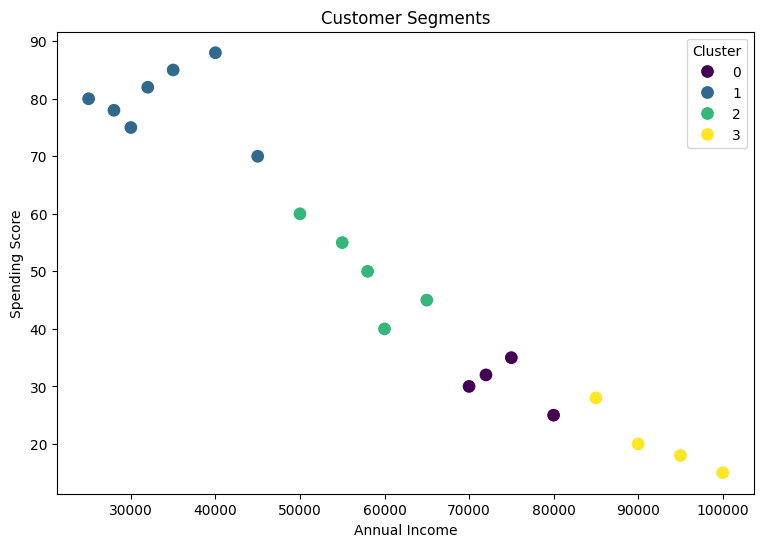

In [11]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="AnnualIncome",
    y="SpendingScore",
    hue="Cluster",
    palette="viridis",
    s=100
)

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")

plt.show()

In [12]:
# Assign meaningful names to customer segments

segment_names = {
    0: "Potential Customers",
    1: "High Engagement Customers",
    2: "Regular Customers",
    3: "High Income Low Engagement"
}

df["Segment"] = df["Cluster"].map(segment_names)

df.head()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseFrequency,Cluster,Segment
0,1,22,25000,80,12,1,High Engagement Customers
1,2,25,30000,75,10,1,High Engagement Customers
2,3,28,35000,85,14,1,High Engagement Customers
3,4,35,50000,60,8,2,Regular Customers
4,5,40,60000,40,6,2,Regular Customers


In [13]:
segment_summary = df.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("AnnualIncome", "mean"),
    Average_Spending=("SpendingScore", "mean"),
    Average_Purchase_Frequency=("PurchaseFrequency", "mean")
).round(2)

segment_summary

,Customers,Average_Age,Average_Income,Average_Spending,Average_Purchase_Frequency
Segment,,,,,
High Engagement Customers,7,26.29,33571.43,79.71,12.43
High Income Low Engagement,4,53.75,92500.00,20.25,2.00
Potential Customers,4,45.25,74250.00,30.50,4.00
Regular Customers,5,36.40,57600.00,50.00,6.80


In [14]:
import plotly.express as px

segment_count = df["Segment"].value_counts().reset_index()

segment_count.columns = ["Segment", "Customers"]

fig = px.bar(
    segment_count,
    x="Segment",
    y="Customers",
    title="Number of Customers by Segment",
    text="Customers"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Number of Customers",
    title_x=0.5
)

fig.show()

In [15]:
fig = px.scatter_3d(
    df,
    x="AnnualIncome",
    y="SpendingScore",
    z="PurchaseFrequency",
    color="Segment",
    hover_data=["CustomerID", "Age"],
    title="3D Customer Segmentation"
)

fig.update_layout(
    scene=dict(
        xaxis_title="Annual Income",
        yaxis_title="Spending Score",
        zaxis_title="Purchase Frequency"
    )
)

fig.show()

In [16]:
fig = px.bar(
    segment_summary.reset_index(),
    x="Segment",
    y="Average_Spending",
    title="Average Spending Score by Customer Segment",
    text="Average_Spending"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Average Spending Score",
    title_x=0.5
)

fig.show()

In [17]:
fig = px.bar(
    segment_summary.reset_index(),
    x="Segment",
    y="Average_Purchase_Frequency",
    title="Purchase Frequency by Customer Segment",
    text="Average_Purchase_Frequency"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Average Purchase Frequency",
    title_x=0.5
)

fig.show()

In [18]:
print("==========================================")
print("      CUSTOMER SEGMENTATION ANALYSIS")
print("==========================================")

print("\nTotal Customers:", len(df))

print("\nCustomer Segments:")
print(df["Segment"].value_counts())

print("\nSegment Analysis:")
display(segment_summary)

      CUSTOMER SEGMENTATION ANALYSIS

Total Customers: 20

Customer Segments:
Segment
High Engagement Customers     7
Regular Customers             5
Potential Customers           4
High Income Low Engagement    4
Name: count, dtype: int64

Segment Analysis:


,Customers,Average_Age,Average_Income,Average_Spending,Average_Purchase_Frequency
Segment,,,,,
High Engagement Customers,7,26.29,33571.43,79.71,12.43
High Income Low Engagement,4,53.75,92500.00,20.25,2.00
Potential Customers,4,45.25,74250.00,30.50,4.00
Regular Customers,5,36.40,57600.00,50.00,6.80


In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Segment counts
segment_counts = df["Segment"].value_counts()

# Segment analysis
summary = df.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Income=("AnnualIncome", "mean"),
    Avg_Spending=("SpendingScore", "mean"),
    Avg_Frequency=("PurchaseFrequency", "mean")
).reset_index()

# Create dashboard
fig = make_subplots(
    rows=2,
    cols=2,
    specs=[
        [{"type": "indicator"}, {"type": "bar"}],
        [{"type": "bar"}, {"type": "pie"}]
    ],
    subplot_titles=(
        "Total Customers",
        "Average Spending Score",
        "Purchase Frequency",
        "Customer Segment Distribution"
    )
)

# KPI
fig.add_trace(
    go.Indicator(
        mode="number",
        value=len(df)
    ),
    row=1,
    col=1
)

# Average Spending
fig.add_trace(
    go.Bar(
        x=summary["Segment"],
        y=summary["Avg_Spending"],
        name="Spending"
    ),
    row=1,
    col=2
)

# Purchase Frequency
fig.add_trace(
    go.Bar(
        x=summary["Segment"],
        y=summary["Avg_Frequency"],
        name="Frequency"
    ),
    row=2,
    col=1
)

# Segment Distribution
fig.add_trace(
    go.Pie(
        labels=segment_counts.index,
        values=segment_counts.values
    ),
    row=2,
    col=2
)

fig.update_layout(
    title_text="Customer Segmentation Dashboard",
    height=900,
    showlegend=False
)

fig.show()

In [20]:
df.to_csv(
    "Customer_Segmentation_Results.csv",
    index=False
)

print("Customer segmentation results saved successfully!")

Customer segmentation results saved successfully!
